In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv('Data/Global_Smartwatch_Marketplace_Insights_2026.csv')

In [3]:
df.columns

Index(['brand', 'condition', 'Case_Size_mm', 'Country', 'price', 'Seller_ID',
       'Is_Worldwide_Shipping', 'title'],
      dtype='object')

In [4]:
df.describe()

,Case_Size_mm,price,Is_Worldwide_Shipping
count,2729.000000,3607.000000,3607.000000
mean,45.942836,617.819739,0.273357
std,3.165700,1071.008291,0.445745
min,26.000000,120.000000,0.000000
25%,44.000000,458.745000,0.000000
50%,46.000000,550.000000,0.000000
75%,49.000000,699.000000,1.000000
max,52.000000,49900.000000,1.000000


In [5]:
df.head(10)

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title
0,Garmin,Used,NaN,Japan,999.76,Seller_0001,1,Garmin fenix 7 Pro Sapphire Dual Power Watch 4...
1,Garmin,Used,NaN,Japan,928.00,Seller_0002,1,Garmin Descent Mk1 Dive Computer Smartwatch GP...
2,Garmin,Used,50.0,Japan,934.92,Seller_0001,1,Garmin Fenix 7X Pro Solar Sapphire 50mm GPS Mu...
3,Garmin,New,NaN,Canada,1200.00,Seller_0003,0,garmin tactix 7 amoled edition BNIB
4,Garmin,Used,43.0,Japan,962.08,Seller_0001,1,Garmin Descent MK2S GPS Watch 43mm Light Sand ...
5,Garmin,Used,NaN,Japan,902.28,Seller_0001,1,Garmin Descent Mk1 Dive Computer Smartwatch GP...
6,Garmin,Used,NaN,Japan,913.36,Seller_0001,1,Garmin Venu X1 Black Smartwatch GPS Multisport...
7,Garmin,Used,47.0,Japan,911.44,Seller_0001,1,Garmin Venu X1 AMOLED Sapphire Titanium 47mm G...
8,Garmin,Used,NaN,Japan,908.06,Seller_0001,1,Garmin Epix GPS Porsche Design Smartwatch
9,Garmin,Used,NaN,Japan,884.90,Seller_0001,1,Garmin Tacx FLUX S Smart Direct Drive Trainer ...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  3607 non-null   object 
 1   condition              3607 non-null   object 
 2   Case_Size_mm           2729 non-null   float64
 3   Country                3607 non-null   object 
 4   price                  3607 non-null   float64
 5   Seller_ID              3607 non-null   object 
 6   Is_Worldwide_Shipping  3607 non-null   int64  
 7   title                  3607 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 225.6+ KB


In [7]:
print(df.nunique())

brand                       5
condition                  14
Case_Size_mm               15
Country                    27
price                    1117
Seller_ID                1754
Is_Worldwide_Shipping       2
title                    3179
dtype: int64


## Missing value: Case_Size_mm
## Cần chuyển sang dạng category: Brand, Condition, Country

In [8]:
convert_category= ['brand', 'condition', 'Country']
for col in convert_category:
    df[col]= df[col].astype('category')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   brand                  3607 non-null   category
 1   condition              3607 non-null   category
 2   Case_Size_mm           2729 non-null   float64 
 3   Country                3607 non-null   category
 4   price                  3607 non-null   float64 
 5   Seller_ID              3607 non-null   object  
 6   Is_Worldwide_Shipping  3607 non-null   int64   
 7   title                  3607 non-null   object  
dtypes: category(3), float64(2), int64(1), object(2)
memory usage: 153.7+ KB


## Vẽ biểu đồ

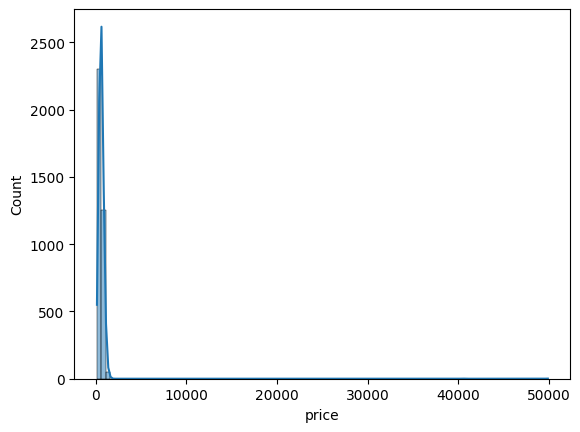

In [10]:
sns.histplot(data= df, x='price', bins=100, kde=True);

## Có giá trị ngoại lệ ở đây khi chủ yếu giá đồng hồ chỉ tập trung khoảng <5000 nhưng có những đồng hồ trị giá 50000

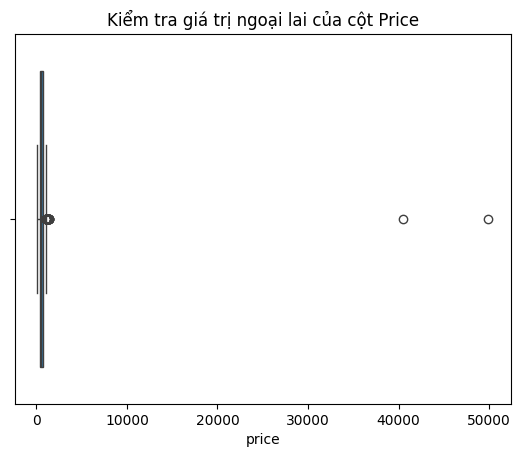

In [11]:
sns.boxplot(data=df, x='price')
plt.title('Kiểm tra giá trị ngoại lai của cột Price')
plt.show()

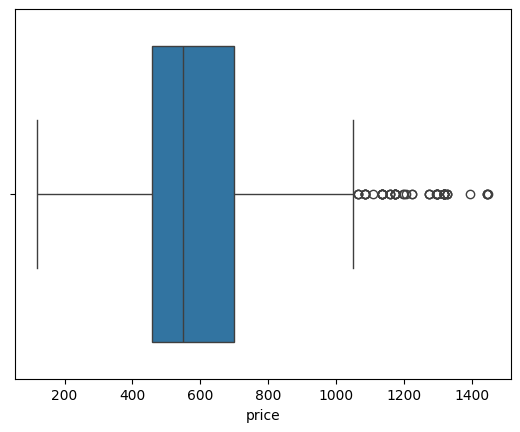

In [12]:
sns.boxplot(data=df[df['price'] < 2000], x='price');

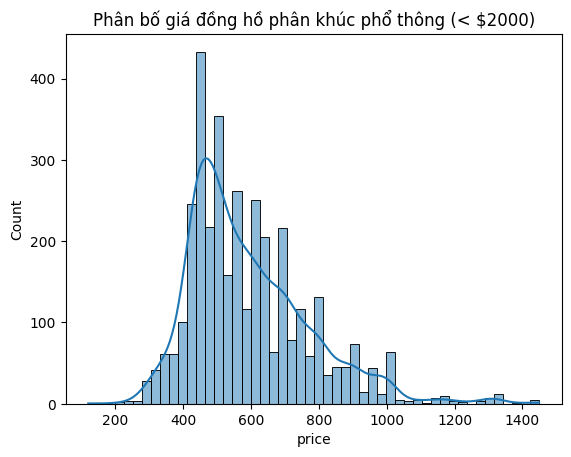

In [13]:
df_filtered = df[df['price'] < 2000]
sns.histplot(data=df_filtered, x='price', bins=50, kde=True)
plt.title('Phân bố giá đồng hồ phân khúc phổ thông (< $2000)')
plt.show()

In [14]:
df_filtered.value_counts()

brand   condition                Case_Size_mm  Country        price   Seller_ID    Is_Worldwide_Shipping  title                                                                           
Apple   Excellent - Refurbished  49.0          United States  839.95  Seller_0033  0                      Apple Watch Ultra 2 [GPS + Cellular 49mm] Smartwatch with Rugged Titanium Case &    6
Garmin  New                      41.0          United States  560.99  Seller_0033  0                      Garmin Venu 4, 41mm, Advanced Health and Fitness GPS Smartwatch, Bright and         5
Apple   Open box                 49.0          United States  450.00  Seller_1270  0                      Apple Watch Ultra 2 49mm Titanium, GPS + Cellular (Open Box)                        4
Garmin  New                      45.0          United States  560.99  Seller_0033  0                      Garmin Venu 4, 45mm, Advanced Health and Fitness GPS Smartwatch, Bright and         4
Apple   New                      49.0        

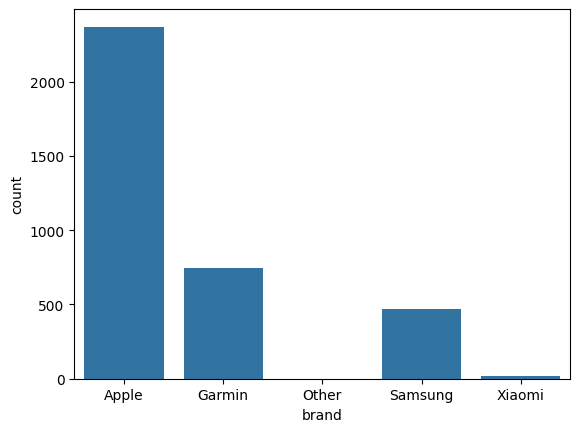

In [15]:
sns.countplot(data=df, x='brand');